# XAUUSDzero D1 breakout research

Separate EMA and confirmed-swing event cohorts. This notebook uses the eight registered signal-time predictors and direction only. OHLC/raw prices, timestamps, entry/exit fields, MAE/MFE, returns and outcomes remain audit data, never predictors. Fixed 2R labels use a 30-bar horizon, ATR 20, buffer 0.05, zero slippage and zero commission. Net R therefore omits trading costs. MAE/MFE are descriptive R-unit excursions over the full available observation window, including after an early exit. Outcomes are observational backtest labels from one market and do not establish live profitability.

In [1]:
import hashlib
import importlib
import json
import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.tree import export_text

repo = Path.cwd() if (Path.cwd() / "app").is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo))
research = importlib.import_module("ML.research")
export_events = research.export_events
eligible_events = research.eligible_events
chronological_split = research.chronological_split
evaluate_models = research.evaluate_models
predictors = research.predictors

In [2]:
# Edit this cell, then run all cells from the top.
SOURCE_PATH = Path(
    os.environ.get(
        "BREAKOUT_SOURCE",
        repo.parent / "data analysis" / "mt5_data" / "XAUUSDzero_D1_max_bars.csv",
    )
)
if not SOURCE_PATH.is_file():
    raise FileNotFoundError(
        f"Edit SOURCE_PATH in this cell to an existing market CSV: {SOURCE_PATH}"
    )
OUTPUT_DIRECTORY = repo / "exports/ML"
CHART_DIRECTORY = None  # Set to a Path to save the figures as PNG files.
ASSET = "XAUUSDzero"
TIMEFRAME = "D1"
SOURCE_TIMEZONE = "UTC"
STRATEGIES = research.STRATEGIES
FEATURE_SETTINGS = {}  # e.g. {"atr_period": 20, "ema_period": 20, "ema_slope_bars": 20}
FEATURE_KEYS = (
    "atr_to_close",
    "ema_slope",
    "ema_distance",
    "candle_range_to_atr",
    "body_size_to_atr",
    "upper_wick_to_atr",
    "lower_wick_to_atr",
    "body_to_range_ratio",
)
FEATURE_NAMES = research.selected_feature_names(FEATURE_KEYS, FEATURE_SETTINGS)
PREDICTORS = (*FEATURE_NAMES, "direction")
DETECTOR_CONFIG = research.EventConfig()
LABEL_CONFIG = research.LabelConfig()
MODEL_SETTINGS = research.ModelSettings()
TOP_FRACTIONS = (0.2, 0.4, 0.6)
MIN_VALIDATION_SUPPORT = 10
CALIBRATION_BINS = 5
FEATURE_BINS = 4
OUTCOME_HISTOGRAM_BINS = 20
R_SUMMARY_PERCENTILES = (0.1, 0.25, 0.5, 0.75, 0.9)
EVALUATION_FIGSIZE = (15, 4)
OUTCOME_FIGSIZE = (14, 6)
WILSON_Z = 1.96

In [3]:
source = SOURCE_PATH
output = OUTPUT_DIRECTORY
paths = {name: output / f"{name}.parquet" for name in STRATEGIES}
if not all(path.exists() for path in paths.values()):
    if any(path.exists() or path.with_suffix(".parquet.json").exists() for path in paths.values()):
        raise FileExistsError(
            "Incomplete research export: move the existing files before regenerating"
        )
    paths = export_events(
        source,
        output,
        asset=ASSET,
        timeframe=TIMEFRAME,
        strategies=STRATEGIES,
        feature_names=FEATURE_NAMES,
        feature_settings=FEATURE_SETTINGS,
        detector_config=DETECTOR_CONFIG,
        label_config=LABEL_CONFIG,
        source_timezone=SOURCE_TIMEZONE,
    )
fingerprint = hashlib.sha256(source.read_bytes()).hexdigest()
frames = {}
for name, path in paths.items():
    metadata = json.loads(Path(str(path) + ".json").read_text(encoding="utf-8"))
    if metadata["source_sha256"] != fingerprint:
        raise ValueError(
            f"{name}: source fingerprint differs; move old export files before regenerating"
        )
    if metadata["model_predictors"] != list(PREDICTORS):
        raise ValueError(f"{name}: export predictor contract differs")
    if (
        metadata["dataset_id"] != f"{ASSET}/{TIMEFRAME}"
        or metadata["label_settings"] != LABEL_CONFIG.as_dict()
        or metadata["detector_settings"]
        != {
            "ema_period": DETECTOR_CONFIG.ema_period,
            "swing_lookback": DETECTOR_CONFIG.swing_lookback,
            "swing_left": DETECTOR_CONFIG.swing_left,
            "swing_right": DETECTOR_CONFIG.swing_right,
            "buffer": DETECTOR_CONFIG.buffer,
            **DETECTOR_CONFIG.detector_settings,
        }
        or metadata.get("feature_settings", {}) != FEATURE_SETTINGS
        or metadata["strategy"] != name
    ):
        raise ValueError(
            f"{name}: export settings differ; move old export files before regenerating"
        )
    frames[name] = pd.read_parquet(path)
print("Source SHA-256:", fingerprint)
display(
    pd.DataFrame(
        {
            name: {"events": len(frame), "unique_ids": frame.id.nunique()}
            for name, frame in frames.items()
        }
    ).T
)

Source SHA-256: 473808c54e9cb2cdfc292524e59f94414f6aeb1b3fa2d1e9e802f3f19e0a7a89


,events,unique_ids
ema_breakout,572,572
swing_breakout,252,252


## Event accounting and outcome uncertainty

Eligibility and exclusions are counted before model selection. Later Wilson 95% intervals describe event-level target-hit proportions; overlapping event windows reduce independence, so treat intervals as descriptive. Ambiguous, censored, unfilled, invalid-entry, incomplete-horizon and missing-predictor rows remain in the audit exports but leave modeling.

In [4]:
def wilson(successes: int, count: int) -> tuple[float, float]:
    if count == 0:
        return (float("nan"), float("nan"))
    z = WILSON_Z
    center = (successes / count + z * z / (2 * count)) / (1 + z * z / count)
    half = (
        z
        * math.sqrt(
            (successes / count) * (1 - successes / count) / count + z * z / (4 * count * count)
        )
        / (1 + z * z / count)
    )
    return center - half, center + half


eligible = {}
for name, frame in frames.items():
    print("\n", name)
    display(
        frame.loc[~frame.eligible]
        .groupby(["label_status", "horizon_complete"], dropna=False)
        .size()
        .rename("excluded_events")
        .to_frame()
    )
    selected = eligible_events(frame, PREDICTORS)
    eligible[name] = selected
    print(
        "Model eligible:",
        len(selected),
        "of",
        len(frame),
        "; excluded:",
        len(frame) - len(selected),
    )
    print("Missing predictors among otherwise eligible:", int(frame.eligible.sum()) - len(selected))


 ema_breakout


,,excluded_events
label_status,horizon_complete,
ambiguous,True,2
invalid_entry,False,1
stop_first,False,2
target_first,False,2


Model eligible: 565 of 572 ; excluded: 7
Missing predictors among otherwise eligible: 0

 swing_breakout


,,excluded_events
label_status,horizon_complete,
ambiguous,True,1
censored,False,1
invalid_entry,False,2
stop_first,False,1


Model eligible: 247 of 252 ; excluded: 5
Missing predictors among otherwise eligible: 0


## Chronological modeling

For each strategy, the final 20% of eligible events is untouched during selection. Development is purged at the test boundary. Three expanding validation folds purge training events whose planned 30-bar outcome end reaches validation start. No fitting, binning or threshold selection uses test outcomes. Small samples or single-class folds remain descriptive only.

In [5]:
results = {}
for name, cohort in eligible.items():
    result = evaluate_models(cohort, MODEL_SETTINGS, PREDICTORS)
    results[name] = result
    print(
        name,
        "development:",
        result["development_count"],
        "test:",
        result["test_count"],
        "test-boundary purge:",
        result["test_boundary_purged"],
        "fold purges:",
        result["fold_purged"],
    )
    if "unavailable" in result:
        print("Model unavailable:", result["unavailable"])
        continue
    comparison = pd.DataFrame(
        {"CV Brier": result["mean_cv_brier"], "untouched test Brier": result["all_test_brier"]}
    )
    display(comparison.sort_values("CV Brier"))
    print("CV selected:", result["selected"], "; XGBoost device:", result["device"])
    print("Shallow tree rules (fit on purged development only):")
    print(
        export_text(
            result["tree_model"], feature_names=list(predictors(cohort, PREDICTORS).columns)
        )
    )

ema_breakout development: 449 test: 113 test-boundary purge: 3 fold purges: [4, 2, 6]


,CV Brier,untouched test Brier
prevalence,0.202006,0.199555
xgb_d3_w10,0.224909,0.215087
xgb_d2_w10,0.225075,0.212390
xgb_d2_w5,0.233117,0.213280
xgb_d3_w5,0.237419,0.217800
tree,0.243387,0.198888


CV selected: prevalence ; XGBoost device: cpu
Shallow tree rules (fit on purged development only):
|--- body_size_to_atr_20 <= 0.98
|   |--- body_size_to_atr_20 <= 0.96
|   |   |--- class: 0
|   |--- body_size_to_atr_20 >  0.96
|   |   |--- class: 1
|--- body_size_to_atr_20 >  0.98
|   |--- upper_wick_to_atr_20 <= 0.19
|   |   |--- class: 0
|   |--- upper_wick_to_atr_20 >  0.19
|   |   |--- class: 0



swing_breakout development: 196 test: 50 test-boundary purge: 1 fold purges: [3, 0, 2]


,CV Brier,untouched test Brier
xgb_d2_w10,0.214412,0.232905
xgb_d3_w10,0.214412,0.232905
prevalence,0.219432,0.283486
xgb_d2_w5,0.223617,0.247970
xgb_d3_w5,0.226488,0.243113
tree,0.253864,0.276140


CV selected: xgb_d2_w10 ; XGBoost device: cpu
Shallow tree rules (fit on purged development only):
|--- ema_distance_20_atr_20 <= 1.61
|   |--- atr_20_to_close <= 0.01
|   |   |--- class: 0
|   |--- atr_20_to_close >  0.01
|   |   |--- class: 0
|--- ema_distance_20_atr_20 >  1.61
|   |--- ema_slope_20_20_atr_20 <= 0.12
|   |   |--- class: 1
|   |--- ema_slope_20_20_atr_20 >  0.12
|   |   |--- class: 0



## Validation-selected favorable conditions and untouched-test assessment

The favorable probability cutoff is chosen from the top 20%, 40%, or 60% of out-of-fold development validation scores by validation lift, requiring at least 10 validation events. The holdout table reports eligible, purged development, validation and test denominators; dates refer to test signals. Baseline is the fitted development prevalence model. Average precision (AP) is shown beside test prevalence because it depends on prevalence. The selected cutoff is applied once to untouched test, without retuning. A zero selected count leaves hit rate and lift undefined.


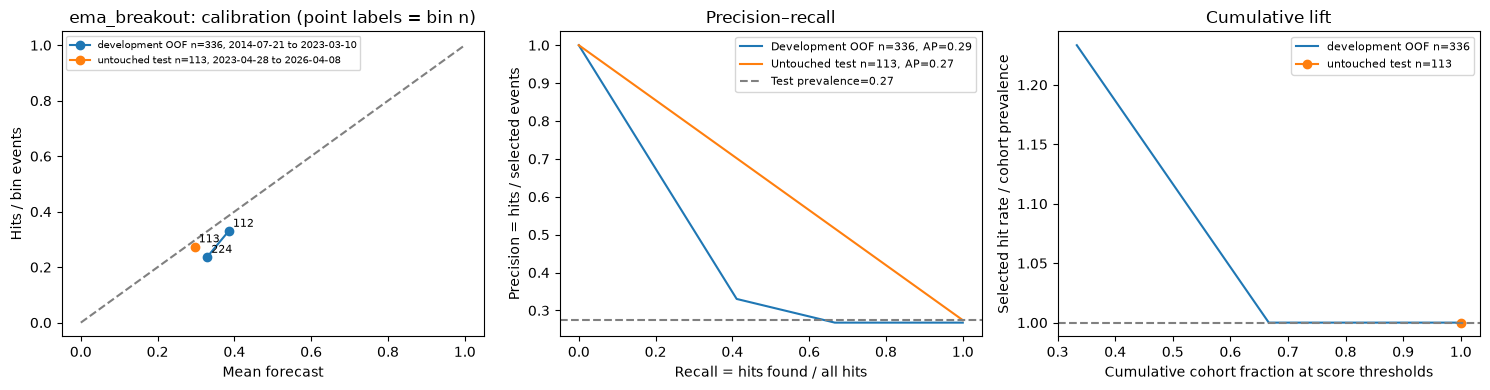

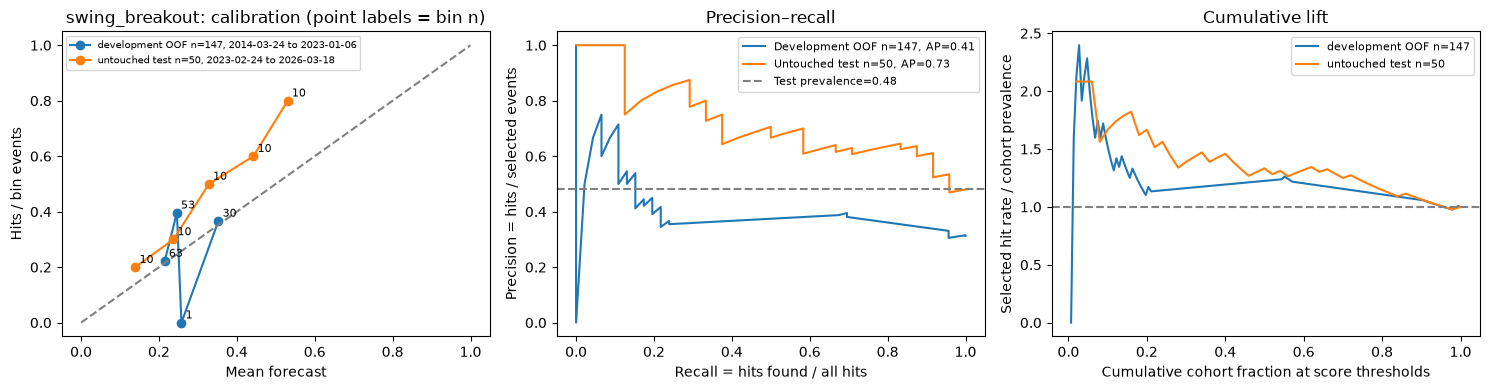

,eligible,development,validation,test,test dates (UTC),selected model,baseline Brier,model Brier,test AP,test prevalence,validation cutoff,validation support,test condition support,test condition hits,test condition hit rate,test lift
detector,,,,,,,,,,,,,,,,
ema_breakout,565,449,336,113,2023-04-28 to 2026-04-08,prevalence,0.1996,0.1996,0.2743,0.2743,0.3853,112,0,0,NaN,NaN
swing_breakout,247,196,147,50,2023-02-24 to 2026-03-18,xgb_d2_w10,0.2835,0.2329,0.7264,0.4800,0.2474,80,34,21,0.6176,1.2868


Cutoffs and model choices use development validation only; test metrics and support are one untouched assessment.
ema_breakout: no test events selected; hit rate and lift are undefined.
swing_breakout: 34 of 50 test events selected; hit rate 0.618; lift 1.287.


In [6]:
holdout_rows = []
for name, result in results.items():
    cohort = eligible[name]
    development, test, _ = chronological_split(cohort, MODEL_SETTINGS.test_fraction)
    if "unavailable" in result:
        holdout_rows.append(
            {
                "detector": name,
                "eligible": len(cohort),
                "development": len(development),
                "test": len(test),
                "status": result["unavailable"],
            }
        )
        continue
    oof = result["oof"]
    truth = development.target_first.iloc[oof.development_index].astype(int).to_numpy()
    probabilities = oof.probability.to_numpy()
    validation_dates = pd.to_datetime(
        development.signal_time.iloc[oof.development_index], unit="s", utc=True
    )
    prevalence = truth.mean()
    choices = []
    for top_fraction in TOP_FRACTIONS:
        cutoff = float(np.quantile(probabilities, 1 - top_fraction))
        selected = probabilities >= cutoff
        if selected.sum() >= MIN_VALIDATION_SUPPORT and prevalence > 0:
            choices.append((truth[selected].mean() / prevalence, cutoff, int(selected.sum())))
    test_truth = test.target_first.astype(int).to_numpy()
    test_prob = result["test_probability"]
    lift, cutoff, validation_support = max(choices) if choices else (float("nan"), float("nan"), 0)
    condition = test_prob >= cutoff if choices else np.zeros(len(test), dtype=bool)
    test_support = int(condition.sum())
    test_hit_rate = float(test_truth[condition].mean()) if test_support else float("nan")
    test_lift = (
        test_hit_rate / test_truth.mean() if test_support and test_truth.mean() else float("nan")
    )
    test_dates = pd.to_datetime(test.signal_time, unit="s", utc=True)
    holdout_rows.append(
        {
            "detector": name,
            "eligible": len(cohort),
            "development": len(development),
            "validation": len(truth),
            "test": len(test),
            "test dates (UTC)": f"{test_dates.iloc[0]:%Y-%m-%d} to {test_dates.iloc[-1]:%Y-%m-%d}",
            "selected model": result["selected"],
            "baseline Brier": result["all_test_brier"]["prevalence"],
            "model Brier": result["test_brier"],
            "test AP": average_precision_score(test_truth, test_prob),
            "test prevalence": test_truth.mean(),
            "validation cutoff": cutoff,
            "validation support": validation_support,
            "test condition support": test_support,
            "test condition hits": int(test_truth[condition].sum()),
            "test condition hit rate": test_hit_rate,
            "test lift": test_lift,
        }
    )
    val_precision, val_recall, _ = precision_recall_curve(truth, probabilities)
    test_precision, test_recall, _ = precision_recall_curve(test_truth, test_prob)
    fig, axes = plt.subplots(1, 3, figsize=EVALUATION_FIGSIZE)
    for label, observed, forecast, dates in (
        ("development OOF", truth, probabilities, validation_dates),
        (
            "untouched test",
            test_truth,
            test_prob,
            pd.to_datetime(test.signal_time, unit="s", utc=True),
        ),
    ):
        if np.unique(forecast).size == 1:
            calibration = pd.DataFrame(
                {
                    "hits": [observed.mean()],
                    "mean_forecast": [forecast[0]],
                    "events": [len(observed)],
                }
            )
        else:
            bins = pd.qcut(forecast, q=CALIBRATION_BINS, duplicates="drop")
            calibration = (
                pd.DataFrame({"bin": bins, "observed": observed, "forecast": forecast})
                .groupby("bin", observed=True)
                .agg(
                    hits=("observed", "mean"),
                    mean_forecast=("forecast", "mean"),
                    events=("observed", "size"),
                )
            )
        legend = f"{label} n={len(observed)}, {dates.min():%Y-%m-%d} to {dates.max():%Y-%m-%d}"
        axes[0].plot(calibration.mean_forecast, calibration.hits, marker="o", label=legend)
        for row in calibration.itertuples():
            axes[0].annotate(
                str(row.events),
                (row.mean_forecast, row.hits),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=8,
            )
    axes[0].plot([0, 1], [0, 1], "--", color="gray")
    axes[0].set(
        title=f"{name}: calibration (point labels = bin n)",
        xlabel="Mean forecast",
        ylabel="Hits / bin events",
    )
    axes[0].legend(fontsize=7)
    development_ap = average_precision_score(truth, probabilities)
    test_ap = average_precision_score(test_truth, test_prob)
    axes[1].plot(
        val_recall,
        val_precision,
        label=f"Development OOF n={len(truth)}, AP={development_ap:.2f}",
    )
    axes[1].plot(
        test_recall,
        test_precision,
        label=f"Untouched test n={len(test_truth)}, AP={test_ap:.2f}",
    )
    axes[1].axhline(
        test_truth.mean(),
        color="gray",
        linestyle="--",
        label=f"Test prevalence={test_truth.mean():.2f}",
    )
    axes[1].set(
        title="Precision–recall",
        xlabel="Recall = hits found / all hits",
        ylabel="Precision = hits / selected events",
    )
    axes[1].legend(fontsize=8)
    for label, observed, forecast in (
        ("development OOF", truth, probabilities),
        ("untouched test", test_truth, test_prob),
    ):
        tiers = (
            pd.DataFrame({"score": forecast, "hit": observed})
            .groupby("score")
            .agg(events=("hit", "size"), hits=("hit", "sum"))
            .sort_index(ascending=False)
        )
        cumulative_events = tiers.events.cumsum()
        axes[2].plot(
            cumulative_events / len(observed),
            tiers.hits.cumsum() / cumulative_events / observed.mean(),
            marker="o" if len(tiers) == 1 else None,
            label=f"{label} n={len(observed)}",
        )
    axes[2].axhline(1, linestyle="--", color="gray")
    axes[2].set(
        title="Cumulative lift",
        xlabel="Cumulative cohort fraction at score thresholds",
        ylabel="Selected hit rate / cohort prevalence",
    )
    axes[2].legend(fontsize=8)
    fig.tight_layout()
    if CHART_DIRECTORY is not None:
        CHART_DIRECTORY.mkdir(parents=True, exist_ok=True)
        fig.savefig(CHART_DIRECTORY / f"{name}-evaluation.png")
    plt.show()
display(pd.DataFrame(holdout_rows).set_index("detector").round(4))
print(
    "Cutoffs and model choices use development validation only; "
    "test metrics and support are one untouched assessment."
)
for row in holdout_rows:
    if "test condition support" not in row:
        continue
    if row["test condition support"] == 0:
        print(f"{row['detector']}: no test events selected; hit rate and lift are undefined.")
    else:
        print(
            f"{row['detector']}: {row['test condition support']} of {row['test']} "
            f"test events selected; hit rate {row['test condition hit rate']:.3f}; "
            f"lift {row['test lift']:.3f}."
        )

## Descriptive outcomes

The outcome histograms separate purged development and untouched test, using eligible events only. Each panel shows nonmissing values over cohort size. Status counts cover every detected event. Net R uses zero-cost label defaults; MAE/MFE span the full observation horizon, including after early exits. These are descriptive paths, not realized trade outcomes or predictors.


ema_breakout all detected event statuses (denominator: 572 )


events
label_status  horizon_complete        
ambiguous     True                   2
invalid_entry False                  1
stop_first    False                  2
              True                 366
target_first  False                  2
              True                 165
timeout       True                  34

Eligible target-first: 165 / 565 ; event-level Wilson 95%: (0.25604684747058987, 0.3308328744062911)
R summary: all detected events, nonmissing values per column; includes ineligible events


,count,mean,std,min,10%,25%,50%,75%,90%,max
net_r,571.0,-0.038738,1.364531,-2.266402,-1.000000,-1.000000,-1.000000,2.000000,2.000000,2.743783
mae_r,571.0,3.510846,3.914821,0.008629,0.380338,0.941226,2.275469,4.460318,8.012741,36.756029
mfe_r,571.0,3.715979,4.584809,0.000000,0.423760,1.031812,2.231322,4.655812,8.426320,41.565198


,events,hits,mean_net_r,median_mae_r,median_mfe_r,hit_rate
year,,,,,,
2011,24,10,0.253376,1.471724,2.015862,0.416667
2012,30,13,0.406761,0.997131,2.262283,0.433333
2013,40,14,0.079821,1.532018,2.236826,0.35
2014,41,10,-0.088471,2.188335,2.096440,0.243902
2015,40,12,-0.037077,2.182480,2.001293,0.3
2016,37,13,0.136848,2.777223,2.289940,0.351351
2017,30,14,0.447462,2.489735,3.161397,0.466667
2018,43,5,-0.583840,2.654813,1.462278,0.116279
2019,37,8,-0.180130,2.330737,1.802800,0.216216


,events,hits,mean_net_r,median_mae_r,median_mfe_r,hit_rate
direction,,,,,,
bearish,279,76,-0.071864,2.407572,1.879323,0.272401
bullish,286,89,-0.007234,2.234823,2.516174,0.311189


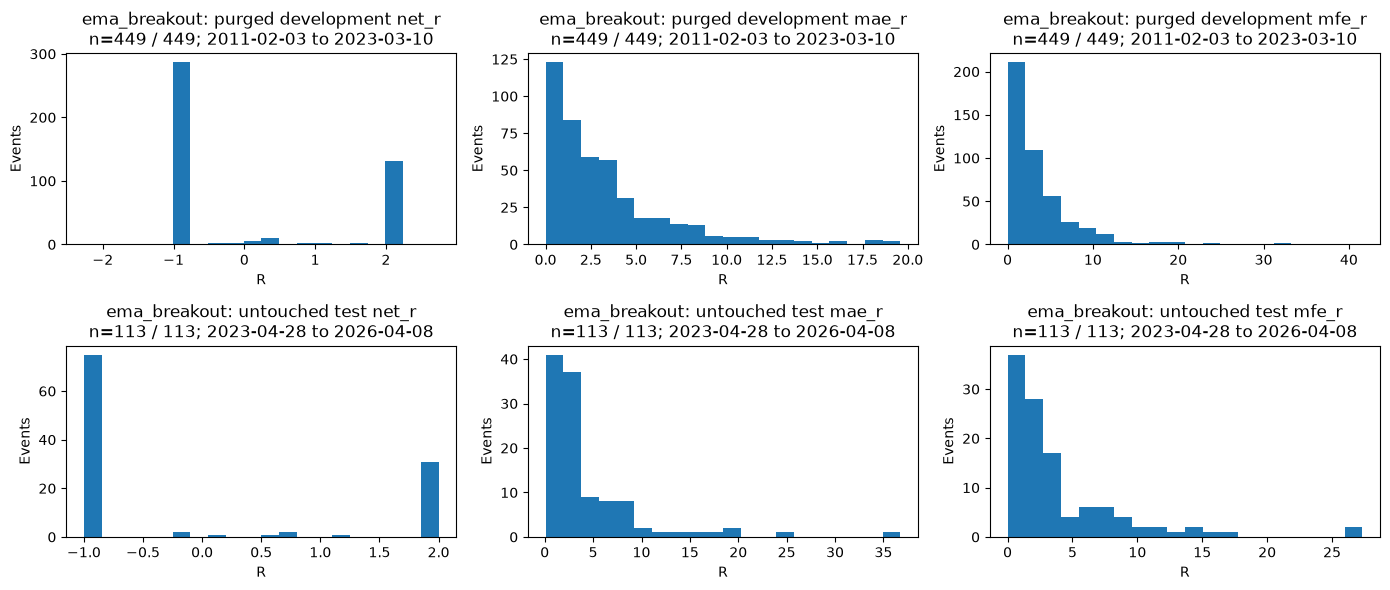

swing_breakout all detected event statuses (denominator: 252 )


events
label_status  horizon_complete        
ambiguous     True                   1
censored      False                  1
invalid_entry False                  2
stop_first    False                  1
              True                 148
target_first  True                  82
timeout       True                  17

Eligible target-first: 82 / 247 ; event-level Wilson 95%: (0.27622168723448093, 0.3928922077494452)
R summary: all detected events, nonmissing values per column; includes ineligible events


,count,mean,std,min,10%,25%,50%,75%,90%,max
net_r,249.0,0.047003,1.477706,-6.071184,-1.000000,-1.000000,-1.000000,2.000000,2.000000,3.652545
mae_r,250.0,2.839982,3.149900,0.006741,0.322129,0.863355,1.904280,3.845727,6.044973,30.150239
mfe_r,250.0,3.451232,3.980826,0.001717,0.413946,0.923513,2.076377,4.305075,8.610900,24.629051


,events,hits,mean_net_r,median_mae_r,median_mfe_r,hit_rate
year,,,,,,
2011,12,4,-0.490678,4.252944,1.954697,0.333333
2012,19,4,-0.211330,1.323688,1.356775,0.210526
2013,13,1,-0.520378,1.541553,1.799257,0.076923
2014,19,4,-0.248709,2.275737,2.396216,0.210526
2015,15,6,0.200000,2.198251,2.012844,0.4
2016,15,4,-0.200000,2.579604,1.296863,0.266667
2017,14,7,0.702510,3.810583,2.565885,0.5
2018,19,7,0.323718,0.991394,1.868069,0.368421
2019,16,4,-0.163224,1.501512,1.727350,0.25


,events,hits,mean_net_r,median_mae_r,median_mfe_r,hit_rate
direction,,,,,,
bearish,108,22,-0.326237,1.982885,1.649190,0.203704
bullish,139,60,0.352067,1.878249,2.769042,0.431655


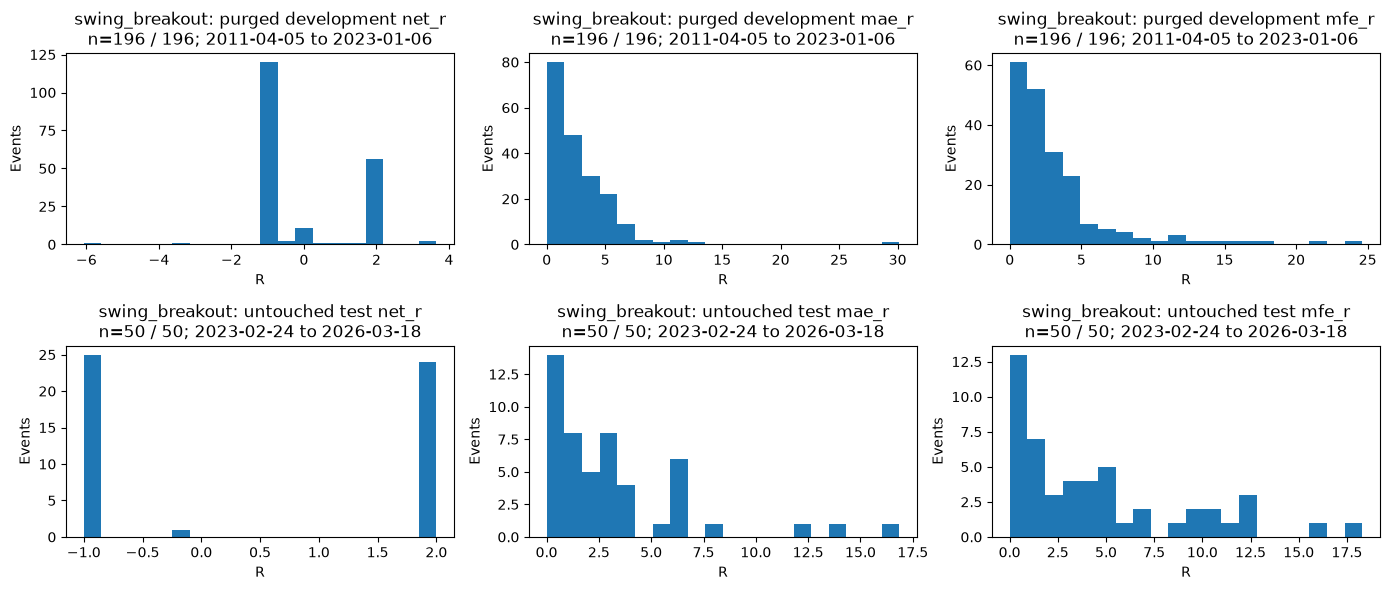

In [7]:
for name, frame in frames.items():
    selected = eligible[name]
    development, test, _ = chronological_split(selected, MODEL_SETTINGS.test_fraction)
    print(name, "all detected event statuses (denominator:", len(frame), ")")
    display(
        frame.groupby(["label_status", "horizon_complete"], dropna=False)
        .size()
        .rename("events")
        .to_frame()
    )
    hits = int(selected.target_first.sum())
    print(
        "Eligible target-first:",
        hits,
        "/",
        len(selected),
        "; event-level Wilson 95%:",
        wilson(hits, len(selected)),
    )
    print(
        "R summary: all detected events, nonmissing values per column; includes ineligible events"
    )
    display(frame[["net_r", "mae_r", "mfe_r"]].describe(percentiles=R_SUMMARY_PERCENTILES).T)
    if selected.empty:
        continue
    yearly = selected.assign(year=pd.to_datetime(selected.signal_time, unit="s", utc=True).dt.year)
    for grouping in ("year", "direction"):
        grouped = yearly.groupby(grouping, observed=True).agg(
            events=("id", "size"),
            hits=("target_first", "sum"),
            mean_net_r=("net_r", "mean"),
            median_mae_r=("mae_r", "median"),
            median_mfe_r=("mfe_r", "median"),
        )
        grouped["hit_rate"] = grouped.hits / grouped.events
        display(grouped)
    fig, axes = plt.subplots(2, 3, figsize=OUTCOME_FIGSIZE)
    for row, (label, cohort) in enumerate(
        (("purged development", development), ("untouched test", test))
    ):
        dates = pd.to_datetime(cohort.signal_time, unit="s", utc=True)
        for axis, column in zip(axes[row], ("net_r", "mae_r", "mfe_r")):
            values = cohort[column].dropna().astype(float)
            axis.hist(values, bins=OUTCOME_HISTOGRAM_BINS)
            axis.set(
                title=(
                    f"{name}: {label} {column}\n"
                    f"n={len(values)} / {len(cohort)}; "
                    f"{dates.min():%Y-%m-%d} to {dates.max():%Y-%m-%d}"
                ),
                xlabel="R",
                ylabel="Events",
            )
    fig.tight_layout()
    if CHART_DIRECTORY is not None:
        CHART_DIRECTORY.mkdir(parents=True, exist_ok=True)
        fig.savefig(CHART_DIRECTORY / f"{name}-outcomes.png")
    plt.show()

## Appendix: development feature bins and tree leaves

These repeated exploratory summaries use purged development only; bin boundaries were not selected on test.


In [8]:
for name, cohort in eligible.items():
    development, _, _ = chronological_split(cohort, MODEL_SETTINGS.test_fraction)
    if "unavailable" not in results[name]:
        leaves = results[name]["tree_model"].apply(predictors(development, PREDICTORS))
        print(name, "development tree leaves")
        display(
            pd.DataFrame({"leaf": leaves, "hit": development.target_first.astype(int)})
            .groupby("leaf")
            .hit.agg(["size", "mean"])
            .rename(columns={"size": "development_support", "mean": "target_hit_rate"})
        )
    for feature in FEATURE_NAMES:
        bins = pd.qcut(development[feature].astype(float), q=FEATURE_BINS, duplicates="drop")
        grouped = development.groupby(bins, observed=True).target_first.agg(["size", "mean"])
        print(name, feature)
        display(grouped.rename(columns={"size": "events", "mean": "target_hit_rate"}))

ema_breakout development tree leaves


,development_support,target_hit_rate
leaf,,
2,316,0.319620
3,11,0.818182
5,78,0.269231
6,44,0.045455


ema_breakout atr_20_to_close


,events,target_hit_rate
atr_20_to_close,,
"(0.0068200000000000005, 0.0111]",113,0.283186
"(0.0111, 0.0139]",112,0.330357
"(0.0139, 0.0166]",112,0.25
"(0.0166, 0.0295]",112,0.321429


ema_breakout ema_slope_20_20_atr_20


...

,events,target_hit_rate
upper_wick_to_atr_20,,
"(-0.001, 0.0883]",49,0.306122
"(0.0883, 0.142]",49,0.285714
"(0.142, 0.235]",49,0.244898
"(0.235, 0.802]",49,0.346939


swing_breakout lower_wick_to_atr_20


,events,target_hit_rate
lower_wick_to_atr_20,,
"(-0.001, 0.089]",49,0.326531
"(0.089, 0.178]",49,0.306122
"(0.178, 0.306]",49,0.244898
"(0.306, 0.731]",49,0.306122


swing_breakout body_to_range_ratio


,events,target_hit_rate
body_to_range_ratio,,
"(0.0823, 0.59]",49,0.306122
"(0.59, 0.716]",49,0.285714
"(0.716, 0.81]",49,0.285714
"(0.81, 0.987]",49,0.306122


## Interpretation

These are event-level associations in one historical XAUUSDzero D1 source. Wilson intervals assume independent events for their nominal coverage, while overlapping 30-bar windows and common market regimes violate that assumption; interpret them descriptively. Calibration bins and lift have no uncertainty interval and small test counts can move them sharply. The untouched test is a single historical period. Detector choices, fixed barriers, intrabar ambiguity, data quality, spread, execution costs, and regime change limit forward claims. Investigate stability and realistic costs before any trading use.
